### What is Jev?
• System 1 Model: Designed for quick, intuition-style binary, choice, or score determinations rather than multi-step reasoning.

• No Text Generation: Does not write replies or explain itself; it outputs structured data and probabilities (like yes/no, selected choices, or numerical ratings).

• Speed and Cost: Up to 200x faster (70–500ms response times) and roughly 400x cheaper ($0.00035 per call) than standard text-generating LLMs

In [ ]:
# ! uv pip install typesafe-sdk
# ! uv add langchain-typesafe


In [12]:
import os
from dotenv import load_dotenv

load_dotenv()

True

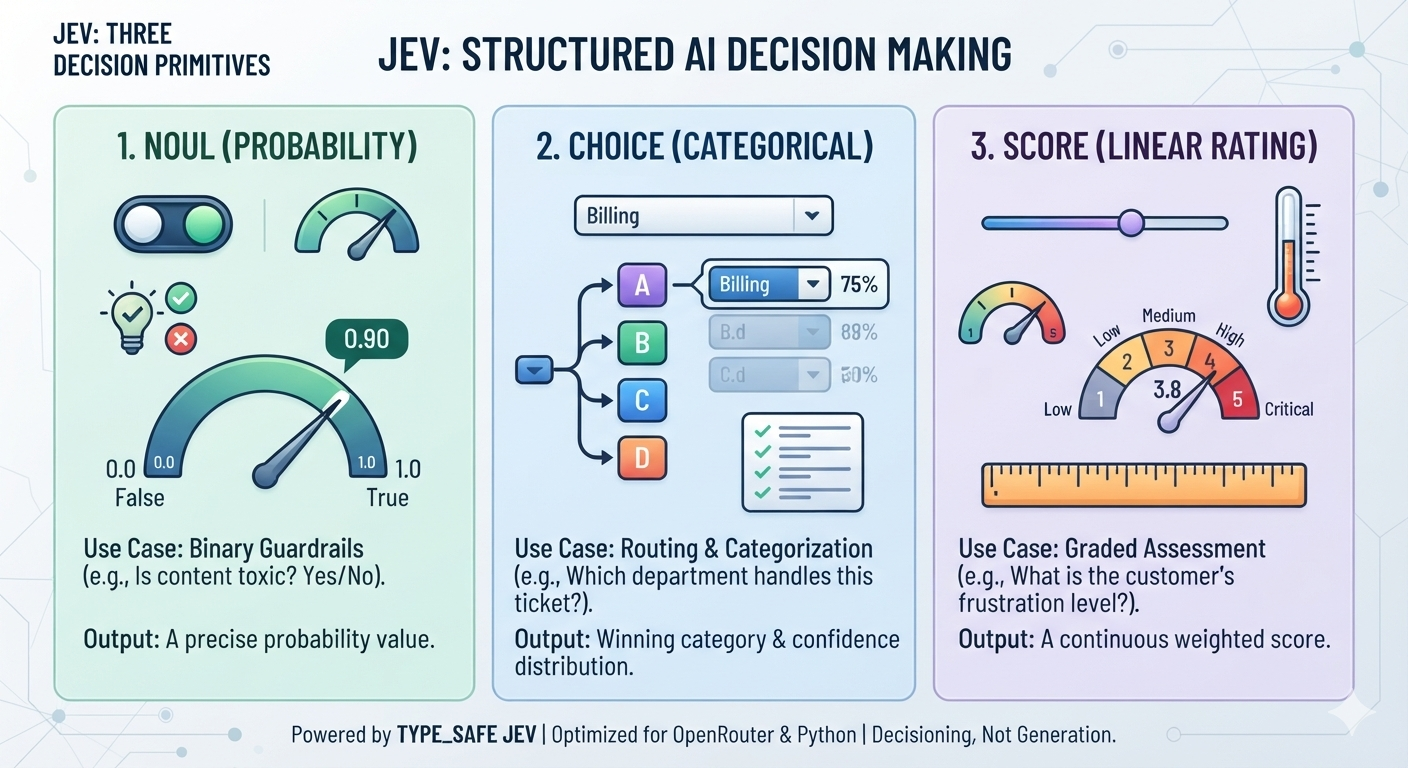

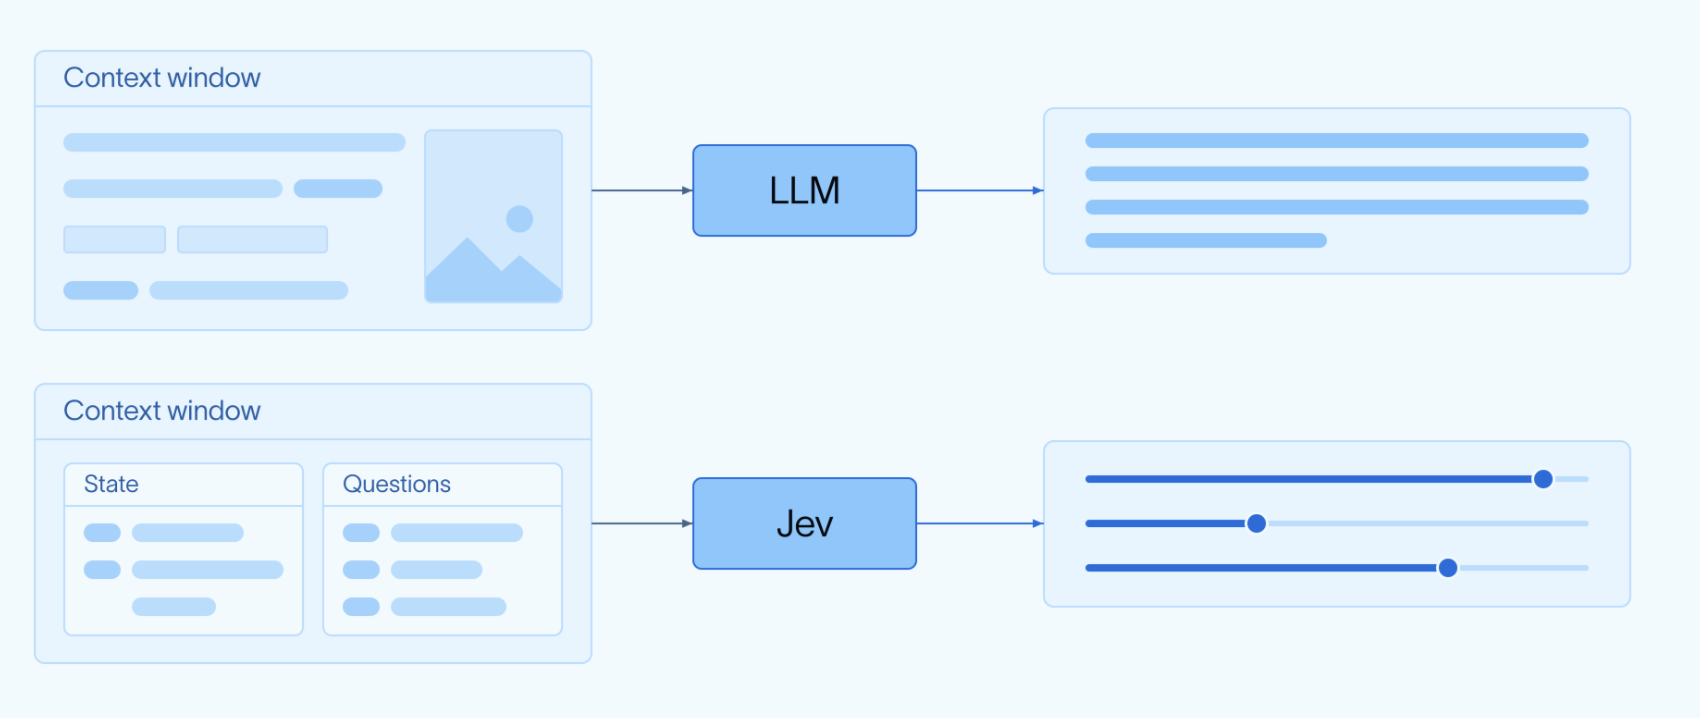

In [8]:
from typesafe_sdk import TypeSafeClient, Noul

# 1. Initialize the client targeting OpenRouter
client = TypeSafeClient(
    api_key=os.environ.get("OPEN_ROUTER_API_KEY", "your_openrouter_api_key_here"),
    base_url="https://openrouter.ai/api"
)

# 2. Define the context/state you want Jev to look at
user_input = "I need to return this item immediately, it arrived broken!"

# 3. Use Jev's System One API to query calibrated probabilities
response = client.system_one(
    state=user_input,
    questions={
        "is_urgent": Noul(
            instructions="Does the user sound upset or require immediate escalation?"
        )
    }
)

# 4. Check the results
print(response)


model='typesafe/jev-1.13-20260917' usage=Usage(input_tokens=288, output_tokens=23) answers={'is_urgent': NoulAnswer(type='noul', noul=0.95)}


In [10]:
print(response.answers["is_urgent"])

type='noul' noul=0.95


In [11]:
import os
from typesafe_sdk import TypeSafeClient, Noul, Choice, Score

# 2. Setup complex incoming context data
customer_ticket = """
Subject: CANNOT LOG IN & DOUBLE CHARGE!
Hey, I've tried resetting my password four times and it still locks me out. 
Also, checking my bank statement, your platform charged me twice ($29.99 x 2). 
Fix this ASAP or I'm deleting my account.
"""

# 3. Fire all three question primitives simultaneously
response = client.system_one(
    state=customer_ticket,
    questions={
        # NOUL with explicit evaluation criteria
        "is_refund_request": Noul(
            instructions="Does the message explicitly ask for money back or mention double billing?",
        ),
        
        # CHOICE for structural form routing
        "target_department": Choice(
            instructions="Which department is best suited to resolve this entire issue?",
            criteria={
                "billing": "Handles payments, refunds, invoicing, and subscriptions.",
                "auth_support": "Handles login failures, password resets, and MFA blocks.",
                "general_tech": "Handles functional UI bugs and software integrations.",
                "retention": "Handles cancellations or users threatening to leave."
            }
        ),
        
        # SCORE for linear scales (returns a float representing the weighted placement)
        "user_frustration": Score(
            instructions="Rate the user's emotional state based on their vocabulary.",
            criteria=[
                "Calm and informative, just stating objective facts.",
                "Irritated, using exclamation marks or emphasizing delay.",
                "Highly volatile, threatening to quit or demanding immediate action."
            ]
        )
    }
)

# 4. Extract the structured outputs cleanly
print("--- Jev Decision Analysis ---")

# Noul returns a float probability
print(f"Refund Probability: {response.answers['is_refund_request'].noul:.2f}")

# Choice returns the winning key and confidence array
winning_dept = response.answers['target_department']
print(f"Route Ticket To: {winning_dept.choice} (Confidence: {winning_dept.confidence:.2f})")

# Score returns a continuous float value between 0.0 and 2.0 (based on your index levels)
frustration_level = response.answers['user_frustration'].score
print(f"Frustration Score: {frustration_level:.2f} / 2.0")


--- Jev Decision Analysis ---
Refund Probability: 0.96
Route Ticket To: auth_support (Confidence: 0.41)
Frustration Score: 2.00 / 2.0
